In [2]:
import os
import fiona
import seaborn as sns
import rasterio
import rasterio.mask
import glob
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
dir1 = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task1"
dir2 = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2"

task1 = []
task2 = []
for root, dirs, files in os.walk(dir1):
    for directory in dirs:
        task1.append(os.path.join(root, directory))
        
for root, dirs, files in os.walk(dir2):
    for directory in dirs:
        task2.append(os.path.join(root, directory))
print(task1)
print("-------------------------------")
print(task2)

['C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task1\\20230405', 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task1\\20240315', 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task1\\20240418', 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task1\\20250404', 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task1\\20250501']
-------------------------------
['C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20230405', 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20240315', 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20240418', 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20250404', 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20250501']


In [16]:
def swe_units(task_dir):
    for root, dirs, files in os.walk(task_dir):
        for directory in dirs:
            date = os.path.basename(directory)

            if os.path.isfile(glob.glob(os.path.join(root,directory, "*EB_swe*"))[0]):
                with rasterio.open(glob.glob(os.path.join(root,directory, "*EB_swe*"))[0]) as src:
                    data = src.read(1, masked=True)
                    profile = src.profile
                    profile.update(dtype=rasterio.float32, nodata=-9999)
                    outfile = os.path.join(root,directory, f"{date}_EB_cm.tif")
                    EB_cm = data * 2.54
                with rasterio.open(outfile, "w", **profile) as dst:
                    dst.write(EB_cm.astype("float32"), 1)
            else:
                print("No energy balance raster found")
                
            if os.path.isfile(glob.glob(os.path.join(root,directory, "*TI_swe*"))[0]):
                with rasterio.open(glob.glob(os.path.join(root,directory, "*TI_swe*"))[0]) as src:
                    data = src.read(1, masked=True)
                    profile = src.profile
                    profile.update(dtype=rasterio.float32, nodata=-9999)
                    outfile = os.path.join(root,directory, f"{date}_TI_cm.tif")
                    TI_cm = data * 2.54
                with rasterio.open(outfile, "w", **profile) as dst:
                    dst.write(TI_cm.astype("float32"), 1)
            else:
                print("No temperature index raster found") 
            
            if os.path.isfile(glob.glob(os.path.join(root,directory, "*swed*"))[0]):
                with rasterio.open(glob.glob(os.path.join(root,directory, "*swed*"))[0]) as src:
                    data = src.read(1, masked=True)
                    profile = src.profile
                    profile.update(dtype=rasterio.float32, nodata=-9999)
                    outfile = os.path.join(root,directory, f"{date}_SnowModel_cm.tif")
                    SM_cm = data * 100
                with rasterio.open(outfile, "w", **profile) as dst:
                    dst.write(SM_cm.astype("float32"), 1)
            else:
                print("No SnowModel raster found") 
            
            if os.path.isfile(glob.glob(os.path.join(root,directory, "*specific_mass*"))[0]):
                with rasterio.open(glob.glob(os.path.join(root,directory, "*specific_mass*"))[0]) as src:
                    data = src.read(1, masked=True)
                    profile = src.profile
                    profile.update(dtype=rasterio.float32, nodata=-9999)
                    outfile = os.path.join(root,directory, f"{date}_iSnobal_cm.tif")
                    iSnobal_cm = data / 10
                with rasterio.open(outfile, "w", **profile) as dst:
                    dst.write(iSnobal_cm.astype("float32"), 1)
            else:
                print("No iSnobal raster found") 
                
                
                        

In [17]:
swe_units("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2")
swe_units("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task1")

In [28]:
basin_shp = "C:/Users/RDCRLSMC/Desktop/GIS/basin/basin_outline.shp"
with fiona.open(basin_shp, "r") as shapefile:
    shapes = [feature["geometry"] for feature in shapefile]

In [13]:
def clip_basin(parent_dir):
    target_string = 'cm'
    for dir in parent_dir:
        for root, dirs, files in os.walk(dir):
            #print(files)
            for filename in files:
                if target_string in filename:
                    name, ext = os.path.splitext(filename)
                    new_name = os.path.join(f"{name}_MC" + ext)
                    out_path = os.path.join(dir, new_name)
                    if os.path.exists(out_path):
                        print(f"Skipping existing raster: {name}")
                    else:       
                        with rasterio.open(os.path.join(dir, filename)) as src:
                            out_image, out_transform = rasterio.mask.mask(src, shapes, crop=True)
# Copy the old profile and update it with new metadata
                            profile = src.profile
                            profile.update({
                            "driver": "GTiff",
                            "height": out_image.shape[1],
                            "width": out_image.shape[2],
                            "transform": out_transform, # <-- Use the new transform from the mask operation
                            "nodata": -9999 # Explicitly set nodata if not already
                             })
                        with rasterio.open(out_path, "w", **profile) as dest:
                                dest.write(out_image)
                    

In [14]:
clip_basin(task1)
clip_basin(task2)

In [18]:
def task_process(task_dir):
    swedata = {}
    for root, dirs, files in os.walk(task_dir):
        for directory in dirs:
            date = os.path.basename(directory)
            swedata[date] = {}
            swedata[date]["Energy Balance"] = glob.glob(os.path.join(root,directory, "*EB_cm_MC*"))[0]
            swedata[date]["Temperature Index"] = glob.glob(os.path.join(root,directory, "*TI_cm_MC*"))[0]
            swedata[date]["SnowModel"] = glob.glob(os.path.join(root,directory, "*SnowModel_cm_MC*"))[0]
            swedata[date]["iSnobal"] = glob.glob(os.path.join(root,directory, "*iSnobal_cm_MC*"))[0]
    return swedata

In [19]:
task2 = task_process("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2")
task1 = task_process("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task1")
print(task2)
print("----------------------------------------------")
print(task1)

{'20230405': {'Energy Balance': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20230405\\20230405_EB_cm_MC.tif', 'Temperature Index': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20230405\\20230405_TI_cm_MC.tif', 'SnowModel': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20230405\\20230405_SnowModel_cm_MC.tif', 'iSnobal': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20230405\\20230405_iSnobal_cm_MC.tif'}, '20240315': {'Energy Balance': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20240315\\20240315_EB_cm_MC.tif', 'Temperature Index': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20240315\\20240315_TI_cm_MC.tif', 'SnowModel': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20240315\\20240315_SnowModel_cm_MC.tif', 'iSnobal': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20240315\\20240315_iSnobal_cm_MC.tif'}, '20240418': {'Energy Balance': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2\\20240

In [30]:
for date, models in task1.items():
    
    # Loop through each model for the current date
        for model_name, raster in models.items():
            with rasterio.open(raster) as src:
                stats = src.statistics(bidx=1)
                print(f"Mean of {model_name} on {date}: {stats.mean}")

Mean of Energy Balance on 20230405: 33.710179642079
Mean of Temperature Index on 20230405: 37.584075385734
Mean of SnowModel on 20230405: 30.339864253809
Mean of iSnobal on 20230405: 28.007836309002
Mean of Energy Balance on 20240315: 28.558759502002
Mean of Temperature Index on 20240315: 16.107999702236
Mean of SnowModel on 20240315: 24.794504876848
Mean of iSnobal on 20240315: 22.099063671499
Mean of Energy Balance on 20240418: 11.567854463345
Mean of Temperature Index on 20240418: 5.816728527229
Mean of SnowModel on 20240418: 10.719636258284
Mean of iSnobal on 20240418: 11.757759387292
Mean of Energy Balance on 20250404: 20.44328166237
Mean of Temperature Index on 20250404: 14.969147825954
Mean of SnowModel on 20250404: 26.469913131203
Mean of iSnobal on 20250404: 19.458258641556
Mean of Energy Balance on 20250501: 3.2386767760156
Mean of Temperature Index on 20250501: 4.9977592130502
Mean of SnowModel on 20250501: 10.748901866852
Mean of iSnobal on 20250501: 7.0120233983446


In [20]:
def calculate_total_weighted_sum(dictionary,  csv_file_path, tasknumber):
    """
    Calculates the sum of all raster pixel values, weighted by the pixel area.

    Args:
        filename (str): The path to the input raster file.

    Returns:
        float: The total weighted sum (e.g., volume if pixel values are height in meters).
    """
    basin_shp = "C:/Users/RDCRLSMC/Desktop/GIS/basin/basin_outline.shp"
    gdf = gpd.read_file(basin_shp)
    total_area = gdf.geometry.area.sum()
    
    results_list = []
    
    for date, models in dictionary.items():
        
        for model_name, raster_path in models.items():
            with rasterio.open(raster_path) as src:
                stats = src.statistics(bidx=1)
                mean = stats.mean
                
                row = {
                    "Task": tasknumber,
                    "Date": date,
                    "Model": model_name,
                    "Mean": mean,
                   
                }
                
            results_list.append(row)
                    
    df = pd.DataFrame(results_list)
    df.to_csv(csv_file_path, index=False)
        


In [21]:
calculate_total_weighted_sum(task2, "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2/Task2_totalSWE.csv", 2)
calculate_total_weighted_sum(task1, "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task1/Task1_totalSWE.csv", 1)

In [24]:
df = pd.read_csv("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/mean_aerial_swe.csv")

In [25]:
df

,Task,Date,Model,Mean,Mean Aerial SWE
0,1,20230405,Energy Balance,33.710180,3.468004e+10
1,1,20230405,Temperature Index,37.584075,3.866539e+10
2,1,20230405,SnowModel,30.339864,3.121276e+10
3,1,20230405,iSnobal,28.007836,2.881364e+10
4,1,20240315,Energy Balance,28.558760,2.938041e+10
5,1,20240315,Temperature Index,16.108000,1.657143e+10
6,1,20240315,SnowModel,24.794505,2.550786e+10
7,1,20240315,iSnobal,22.099064,2.273486e+10
8,1,20240418,Energy Balance,11.567854,1.190067e+10
9,1,20240418,Temperature Index,5.816729,5.984079e+09


C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29288\657514.py:1: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  g = sns.relplot(
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29288\657514.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


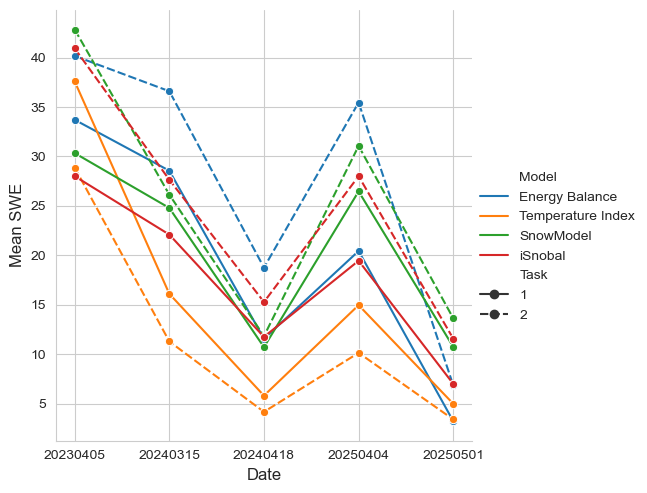

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29288\657514.py:18: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  g = sns.relplot(
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29288\657514.py:18: UserWarning: 
The markers list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


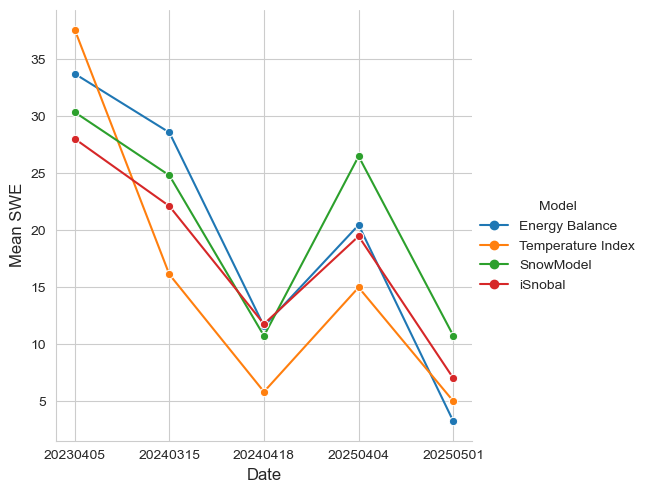

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29288\657514.py:35: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  g = sns.relplot(
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29288\657514.py:35: UserWarning: 
The markers list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


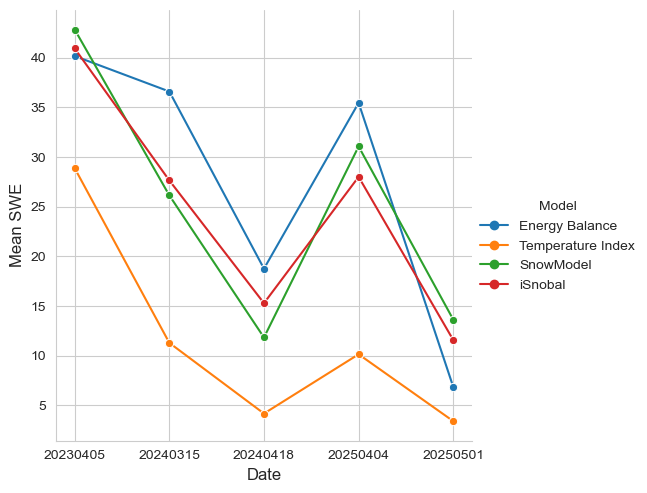

In [27]:


g = sns.relplot(
    data=df,
    x= df['Date'].astype(str),
    y='Mean',
    hue='Model',
    palette=sns.color_palette(),
    style='Task',
    kind='line',
    markers = 'o',
    legend='full'
)

g.set_axis_labels("Date", "Mean SWE", fontsize=12)
plt.title("", size=14) # Add title
plt.show()


g = sns.relplot(
    data=df[df['Task']==1],
    x= df['Date'].astype(str),
    y='Mean',
    hue='Model',
    palette=sns.color_palette(),
    style='Model',
    markers='o',
    dashes=False,  
    kind='line'
)

g.set_axis_labels("Date", "Mean SWE", fontsize=12)
plt.title("", size=14) # Add title
plt.show()


g = sns.relplot(
    data=df[df['Task']==2],
    x= df['Date'].astype(str),
    y='Mean',
    hue='Model',
    palette=sns.color_palette(),
    style='Model',
    markers='o',
    dashes=False, 
    kind='line'
)

g.set_axis_labels("Date", "Mean SWE", fontsize=12)
plt.title("", size=14) # Add title
plt.show()

In [28]:
df_iSnobal = df[(df['Model'] == 'iSnobal') | (df['Model'] == 'SnowModel')]
df_HMS = df[(df['Model'] == 'Energy Balance') | (df['Model'] == 'Temperature Index')]

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29288\2297692938.py:1: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  g = sns.relplot(
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29288\2297692938.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


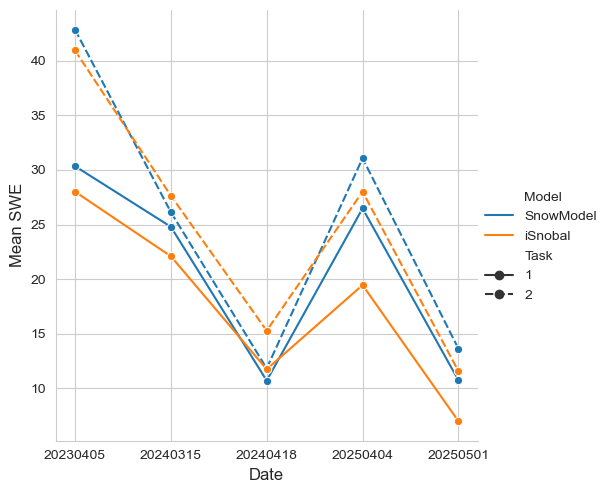

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29288\2297692938.py:16: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  g = sns.relplot(
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29288\2297692938.py:16: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


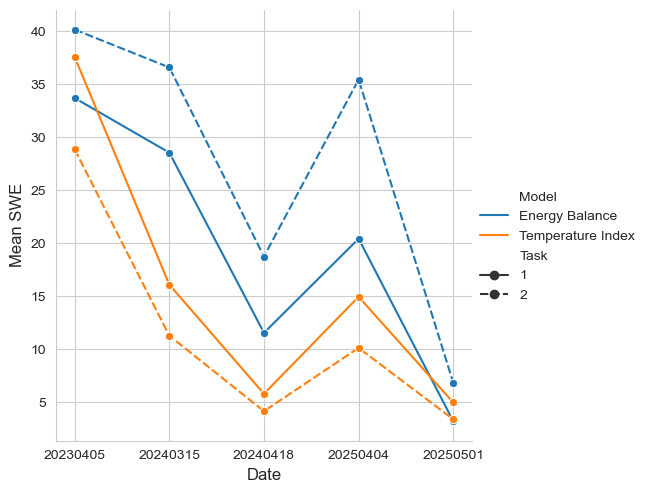

In [29]:
g = sns.relplot(
    data=df_iSnobal,
    x= df['Date'].astype(str),
    y='Mean',
    hue='Model',
    palette=sns.color_palette(),
    style=df['Task'].astype(str),
    markers='o',
    kind='line'
)

g.set_axis_labels("Date", "Mean SWE", fontsize=12)
plt.title("", size=14) # Add title
plt.show()

g = sns.relplot(
    data=df_HMS,
    x= df['Date'].astype(str),
    y='Mean',
    hue='Model',
    palette=sns.color_palette(),
    style=df['Task'].astype(str),
    markers='o',
    kind='line'
)

g.set_axis_labels("Date", "Mean SWE", fontsize=12)
plt.title("", size=14) # Add title
plt.show()

### Mean Areal SWE
Options:

-  I could break Mores Creek into "zones" based on elevation. I.e., top third, middle third, bottom third. Find mean within zone.
- OR, bin by elevation (every 500 or 1000 feet), but look at SWE in terms of thousand acre feet
- Create histogram of total SWE (TAF) byt elevation